In [1]:
!pip install nltk

## Library import :

In [2]:
## Data handling :
import pandas as pd
import numpy as np

## Text preprocessing :
import re
import nltk 
from nltk.corpus import stopwords

## Feature extraction :
from sklearn.feature_extraction.text import TfidfVectorizer

## Train test split :
from sklearn.model_selection import train_test_split

## ML Algorithm :
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

## Model evaluation :
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

## Dataset load :

In [3]:
df =pd.read_csv("C:/Users/nitish bajpai/Downloads/archive (3)/train.csv")

In [4]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [6]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [8]:
df.shape

(159571, 8)

In [9]:
df['toxic'].value_counts()

toxic
0    144277
1     15294
Name: count, dtype: int64

In [10]:
toxic =df[df['toxic']==1]
non_toxic = df[df['toxic']==0]

In [11]:
toxic_sample =toxic.sample(n =15000, random_state =42)             
non_toxic_sample = non_toxic.sample(n =15000 , random_state =42)

In [12]:
df = pd.concat([toxic_sample , non_toxic_sample])
df = df.sample(frac = 1 , random_state =42)


In [13]:
df['toxic'].value_counts()

toxic
1    15000
0    15000
Name: count, dtype: int64

## Stopwords download :

In [14]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\nitish
[nltk_data]     bajpai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Text Cleaning function :

In [15]:
# Text preprocessing: cleaning + stopwords removal + stemming

stop_words = set(stopwords.words('english'))


def clean_text(text):
    text = text.lower()   # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)# remove special characters
    words =text.split()
    words = [(w) for w in words if w not in stop_words and len(w) > 2]   # remove stopwords 
    return " ".join(words)


## Cleaning apply :

In [16]:
df['clean_comment'] = df['comment_text'].apply(clean_text)

## Feature extraction :

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features =25000)

x = vectorizer.fit_transform(df['clean_comment'])

In [18]:
## Target varible :
y = df['toxic']

## Train_test_split :

In [19]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y, test_size = 0.2 , random_state = 42)

## Model training :

In [20]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train , y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Model prediction :

In [21]:
from sklearn.metrics import accuracy_score
pred = model.predict(x_test)
acc = accuracy_score(y_test , pred)

In [22]:
print("Model Accuracy :" , acc)

Model Accuracy : 0.885


In [23]:
print(pred[:50])

[1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0
 0 0 0 1 1 0 1 0 0 0 1 0 0]


In [24]:
pred =model.predict(x_test)
result = df.loc[y_test.index , ['comment_text' , 'toxic']]
result['Predicted'] =pred
result.head()

,comment_text,toxic,Predicted
146935,"Also, I like to have sex with little boys.",1,1
132808,"""\n\nUk55\nI fess-up, you have caught me again...",1,1
44488,No where on allports menu are fries listed as ...,1,1
30264,of course after being fucked up the arse,1,1
83373,"""\n\n Diane and Endymion \n\n Diane and En...",0,1


In [25]:
new_comment = ["you are stupid"]

new_comment_vec = vectorizer.transform(new_comment)

prediction = model.predict(new_comment_vec)

print(prediction)

[1]


## Confusion matrix :

In [26]:
cm = confusion_matrix(y_test, pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2598  359]
 [ 331 2712]]


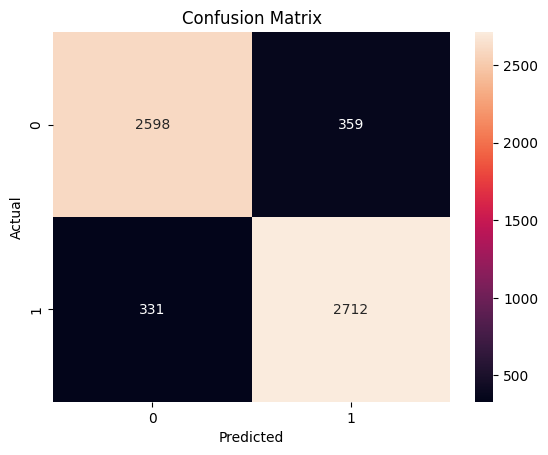

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Classification report :

In [28]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      2957
           1       0.88      0.89      0.89      3043

    accuracy                           0.89      6000
   macro avg       0.89      0.88      0.88      6000
weighted avg       0.89      0.89      0.88      6000



In [29]:
pred = model.predict(x_test)
print("Accuracy :" , accuracy_score(y_test , pred))

Accuracy : 0.885


## Toxicity probability score :

In [35]:

comment = input("Enter comment: ")

cleaned = clean_text(comment)

vector = vectorizer.transform([cleaned])

prob = model.predict_proba(vector)

print("Toxic Probability:", prob[0][1])


Enter comment:  ugly


Toxic Probability: 0.9180503137300815


## Prevention Demo :

In [31]:
from IPython.display import clear_output

In [32]:

comment = input("Enter a comment: ")

cleaned = clean_text(comment)

vector = vectorizer.transform([cleaned])

result = model.predict(vector)

if result[0] == 1:
    clear_output()
    
    print("⚠ Toxic Comment Detected")
    print("Comment Blocked Before Publishing")




Enter a comment:  miss


In [36]:
# Saving of Model and vectorizer 

import pickle

pickle.dump(model, open('model.pkl','wb'))
pickle.dump(vectorizer, open('tfidf.pkl','wb'))